---
downloads: []
---

# Modelos estocasticos de Poisson


En este capítulo introduciremos algunas nociones básicas de probabilidad que nos permitirán construir modelos para describir fenómenos en los que existe **incertidumbre y ocurrencia aleatoria de eventos**.

Un **experimento aleatorio** es un procedimiento cuyo resultado no puede determinarse con certeza antes de realizarlo, aunque se conocen los posibles resultados. Lanzar una moneda, registrar el número de clientes que llegan a un establecimiento o contar las fallas de una máquina durante un período de tiempo son ejemplos de experimentos aleatorios.

En muchas situaciones de interés no buscamos predecir exactamente el resultado de un experimento, sino  describir y cuantificar las probabilidades de los diferentes resultados posibles. Estas ideas constituyen la base de los modelos probabilísticos.

Entre estos modelos, la **distribución de Poisson** es especialmente importante para representar el número de veces que ocurre un determinado evento durante un intervalo de tiempo o dentro de una región del espacio. Sus aplicaciones incluyen el número de llamadas recibidas, clientes que llegan, fallas de un componente, defectos en materiales o partículas detectadas por un instrumento.

El capítulo comienza con algunas nociones fundamentales de probabilidad y variables aleatorias. Posteriormente estudiaremos la distribución de Poisson, su interpretación y sus aplicaciones, y finalmente introduciremos el proceso de Poisson y su simulación.




## 1. Fundamentos matemáticos: cálculo de probabilidades

La teoría de la probabilidad proporciona un lenguaje matemático para describir fenómenos aleatorios. Para construir este lenguaje necesitamos especificar cuáles son los posibles resultados de un experimento y cómo se asignan probabilidades a los eventos que pueden ocurrir.


### 1.1. Experimento aleatorio
Un experimento aleatorio es un procedimiento que puede repetirse bajo condiciones similares, pero cuyo resultado no puede determinarse con certeza antes de realizarlo.

Por ejemplo: lanzar una moneda y observar si se obtiene cara o sello;
lanzar un dado y observar el número obtenido;
seleccionar una persona al azar y registrar su edad;
observar si llueve o no en un día determinado.

Aunque no podamos predecir con certeza el resultado de una realización particular, podemos describir los resultados posibles y asignar probabilidades a los eventos asociados con ellos. Por ejemplo, al lanzar un dado, los resultados posibles son

$$
{1,2,3,4,5,6}.
$$


### 1.2. Espacio muestral

Un espacio muestral es el conjunto de todos los resultados posibles de un experimento aleatorio. Se denota generalmente por $\Omega$. Por ejemplo, si lanzamos una moneda, podemos considerar

$$
\Omega = \{\text{Cara},\text{Cruz}\}.
$$

Si lanzamos un dado de seis caras,

$$
\Omega = \{1,2,3,4,5,6\}.
$$

Si lanzamos dos dados y distinguimos el resultado de cada dado, podemos escribir

$$
\Omega =
\{(1,1),(1,2),\ldots,(6,5),(6,6)\}.
$$

El espacio muestral puede ser finito, infinito numerable o incluso no numerable.



### 1.3. Eventos

Un evento  es un subconjunto del espacio muestral. Por ejemplo, al lanzar un dado, podemos definir

$$
A=\{2,4,6\},
$$

donde $A$ representa el evento "obtener un número par". Los eventos pueden combinarse mediante las operaciones usuales de conjuntos:

* $A\cup B$: ocurre $A$ o $B$.
* $A\cap B$: ocurren simultáneamente $A$ y $B$.
* $A^c$: no ocurre $A$.
* $A\setminus B$: ocurre $A$ pero no $B$.



### 1.4. La función de Probabilidad

Una probabilidad es una función que asigna a cada evento $A$ un número entre $0$ y $1$:

$$
P:\mathcal{F}\longrightarrow [0,1],
$$

donde $\mathcal{F}$ representa la colección de eventos a los que se les puede asignar probabilidad. La función $P$ satisface los siguientes axiomas.

>* **No negatividad:**
>$$
P(A)\geq 0.
$$

>* **Normalización:**
>$$
P(\Omega)=1.
$$

>* **Aditividad:**
>Si $A_1,A_2,\ldots$ son eventos mutuamente excluyentes, entonces
>$$
P\left(\bigcup_{i=1}^{\infty}A_i\right)
=
\sum_{i=1}^{\infty}P(A_i).
$$

<br>

Estos axiomas constituyen la base matemática de la teoría de la probabilidad.



### 1.5. Algunas reglas básicas de probabilidad

Si $A$ y $B$ son eventos, entonces

$$
P(A\cup B)
=
P(A)+P(B)-P(A\cap B).
$$

Si $A$ y $B$ son mutuamente excluyentes,

$$
P(A\cap B)=0,
$$

y por tanto

$$
P(A\cup B)=P(A)+P(B).
$$

La probabilidad del evento complementario es

$$
P(A^c)=1-P(A).
$$



### 1.6. Probabilidad condicional

La probabilidad de que ocurra $A$ sabiendo que ha ocurrido $B$ se define como

$$
P(A\mid B)
=
\frac{P(A\cap B)}{P(B)},
\qquad P(B)>0.
$$

Esta definición permite describir situaciones en las que la información disponible modifica las probabilidades. De manera equivalente,

$$
P(A\cap B)
=
P(A\mid B)P(B).
$$

Esta expresión será especialmente importante al estudiar las trayectorias de las cadenas de Markov.



### 1.7. Independencia de eventos

Dos eventos $A$ y $B$ son independientes si la ocurrencia de uno no modifica la probabilidad del otro. Matemáticamente,

$$
P(A\cap B)=P(A)P(B).
$$

Equivalentemente, cuando $P(B)>0$,

$$
P(A\mid B)=P(A).
$$

Es importante distinguir entre **eventos mutuamente excluyentes** e **independientes**. Si dos eventos tienen probabilidad positiva y son mutuamente excluyentes, no pueden ser independientes.



 * ####  Ejemplo: lanzamiento de un dado

Consideremos un dado justo.

Definimos

$$
A=\{2,4,6\},
$$

como el evento de obtener un número par, y

$$
B=\{4,5,6\},
$$

como el evento de obtener un número mayor o igual que $4$. Entonces

$$
P(A)=\frac{3}{6}=\frac12,
$$

y

$$
P(B)=\frac{3}{6}=\frac12.
$$

Además,

$$
A\cap B=\{4,6\},
$$

por lo que

$$
P(A\cap B)=\frac{2}{6}=\frac13.
$$

Así,

$$
P(A\cup B)
=
\frac12+\frac12-\frac13
=
\frac23.
$$



## 2. Interpretaciones de la probabilidad

Hasta ahora hemos utilizado las reglas de la probabilidad para calcular la probabilidad de diferentes eventos. Sin embargo, es importante preguntarnos qué significa afirmar que un evento tiene una determinada probabilidad.

Existen diferentes interpretaciones de la probabilidad. En este capítulo nos interesan principalmente dos: el **enfoque clásico** y el **enfoque frecuentista**.


### 2.1. Enfoque clásico

El enfoque clásico permite calcular la probabilidad de un evento cuando los resultados posibles de un experimento son equiprobables.

Si un experimento tiene $N$ resultados posibles y $n$ de ellos pertenecen al evento $A$, entonces

$$
P(A)=\frac{n}{N}.
$$

Por ejemplo, al lanzar un dado equilibrado, existen seis resultados posibles y todos tienen la misma probabilidad. Si $A$ es el evento «obtener un número par», entonces

$$
A=\{2,4,6\}
$$

y, por tanto,

$$
P(A)=\frac{3}{6}=\frac12.
$$

En este caso podemos determinar la probabilidad sin realizar el experimento, utilizando los resultados posibles y la hipótesis de que son equiprobables.


### 2.2. Enfoque frecuentista

En muchas situaciones no es posible determinar la probabilidad contando resultados equiprobables. En estos casos podemos utilizar datos obtenidos mediante la repetición del experimento.

Si realizamos $N$ repeticiones y el evento $A$ ocurre $n_A$ veces, podemos calcular su frecuencia relativa:

$$
f_N(A)=\frac{n_A}{N}.
$$

Esta frecuencia relativa puede utilizarse para estimar la probabilidad:

$$
P(A)\approx f_N(A)=\frac{n_A}{N}.
$$

Por ejemplo, si lanzamos una moneda $1000$ veces y obtenemos $487$ caras, la frecuencia relativa es

$$
f_{1000}(\text{cara})
=
\frac{487}{1000}
=
0.487.
$$

Podemos utilizar este valor como una estimación de la probabilidad de obtener cara.



La idea fundamental del enfoque frecuentista es que, al aumentar el número de repeticiones, la frecuencia relativa tiende a estabilizarse alrededor de un determinado valor.


### 2.3. Comparación entre los enfoques clásico y frecuentista

Consideremos ahora el lanzamiento simultáneo de dos dados equilibrados y estudiemos la suma de los valores obtenidos.


#####  **Enfoque clásico:**

Cada dado tiene seis resultados posibles, por lo que existen

$$
6\times6=36
$$

resultados posibles para el lanzamiento de los dos dados.

Para obtener una suma igual a $7$, las combinaciones posibles son

$$
(1,6),(2,5),(3,4),(4,3),(5,2),(6,1).
$$

Hay, por tanto, $6$ resultados favorables de los $36$ posibles. Según el enfoque clásico,

$$
P(\text{suma}=7)
=
\frac{6}{36}
=
\frac16
\approx0.1667.
$$

Además, podemos determinar la probabilidad clásica de cada una de las posibles sumas:

$$
2,3,\ldots,12.
$$

La suma $7$ es la más probable, porque puede obtenerse de seis maneras diferentes.


#### **Enfoque frecuentista mediante simulación**
Ahora realizaremos la simulación del experiemnto aleatorio de lanzar los dos dados  y utilizaremos los resultados obtenidos para calcular las frecuencias relativas.

Para generar los resultados aleatorios podemos utilizar la función `np.random.randint` de **NumPy**. Esta función genera números enteros aleatorios dentro de un intervalo determinado.

Por ejemplo,

```python
np.random.randint(1, 7)
```

genera un número entero aleatorio entre $1$ y $6$. El límite superior, $7$ en este caso, no está incluido.

También podemos indicar cuántos números queremos generar:

```python
np.random.randint(1, 7, 10)
```

genera un arreglo con $10$ números enteros aleatorios entre $1$ y $6$.

Esta función resulta especialmente útil para simular experimentos como el lanzamiento de dados, donde cada número generado representa el resultado de un lanzamiento. En nuestro caso, utilizaremos dos arreglos para simular los resultados de los dos dados y, a partir de ellos, calcularemos las sumas obtenidas.

A diferencia de los modelos continuos y discretos estudiados anteriormente, en este caso nos interesa observar cómo se distribuyen los resultados de un experimento aleatorio. Para ello utilizaremos un histograma, el cual definimos a continuación:


> **Histograma :**
> Es una representación gráfica que permite observar cómo se distribuyen los valores de un conjunto de datos. En una simulación, permite visualizar con qué frecuencia aparece cada resultado.


Por ejemplo, al lanzar dos dados muchas veces, podemos construir un histograma de las sumas obtenidas. La altura de cada barra representa la frecuencia con la que aparece cada suma y nos permite identificar cuáles resultados son más frecuentes.

Si utilizamos la **frecuencia relativa**, la altura de cada barra representa la proporción de veces que se obtuvo cada resultado respecto al número total de lanzamientos. Así, al realizar un número grande de simulaciones, podemos observar cómo la distribución obtenida experimentalmente se aproxima a la **distribución de probabilidad teórica**.

A continuación, realizaremos la simulación y construiremos el histograma de las sumas de los dos dados.



In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Número de lanzamientos
N = 100000

# Lanzamiento de los dos dados
dado1 = np.random.randint(1, 7, N)
dado2 = np.random.randint(1, 7, N)

# Suma de los dados
suma = dado1 + dado2

# Frecuencia de cada suma
valores, frecuencias = np.unique(suma, return_counts=True)

# Frecuencia relativa
frecuencias_relativas = frecuencias / N

# Histograma
plt.bar(valores, frecuencias_relativas)

plt.xlabel('Suma de los dos dados')
plt.ylabel('Frecuencia relativa')
plt.title('Distribución frecuentista de la suma de dos dados')

plt.xticks(valores)
plt.grid(axis='y')
plt.show()

El gráfico muestra que la suma 7 aparece con mayor frecuencia que las demás sumas. Tambien podemos calcular directamente la frecuencia relativa correspondiente a la suma 7:

In [ ]:
frecuencia_7 = np.sum(suma == 7) / N
print("Frecuencia relativa de obtener 7:", frecuencia_7)
print("Probabilidad clásica:", 1/6)

Al utilizar un número suficientemente grande de lanzamientos, la frecuencia relativa debería aproximarse al valor obtenido mediante el enfoque clásico:

$$
\frac{\text{número de veces que aparece 7}}{N}
\approx
\frac16.
$$

Por ejemplo, una simulación podría producir un resultado cercano a

$$
f_N(7)\approx0.167,
$$

mientras que el valor clásico es

$$
P(7)=\frac16\approx0.1667.
$$

Los valores no tienen por qué coincidir exactamente, ya que la simulación representa un número **finito** de realizaciones. Sin embargo, al aumentar $N$, esperamos que la frecuencia relativa se aproxime cada vez más a la probabilidad teórica.


El ejemplo anterior muestra la relación entre ambos enfoques. El **enfoque clásico** permite obtener una probabilidad a partir de un modelo en el que conocemos los resultados posibles y podemos considerarlos equiprobables. El **enfoque frecuentista**, en cambio, utiliza las observaciones realizadas para estimar esa probabilidad mediante una frecuencia relativa.


### 2.4. La clave de todo: Ley de los grandes números

La relación entre la frecuencia relativa y la probabilidad no es solamente una observación experimental. Está fundamentada en un **teorema matemático** conocido como la **Ley de los Grandes Números**.

De manera intuitiva, este teorema establece que, al repetir muchas veces un experimento aleatorio bajo las mismas condiciones, la frecuencia relativa de un evento tiende a aproximarse a su probabilidad.

Si $A$ es un evento y $n_A$ es el número de veces que ocurre en $N$ repeticiones, entonces

$$
f_N(A)=\frac{n_A}{N}
\longrightarrow
P(A)
\qquad\text{cuando}\qquad N\longrightarrow\infty.
$$

Por ejemplo, para el lanzamiento de dos dados,

$$
P(\text{suma}=7)=\frac{1}{6}\approx0.1667.
$$

Al aumentar el número de lanzamientos, la frecuencia relativa de obtener una suma igual a $7$ tiende a aproximarse a este valor. Sin embargo, para un número finito de lanzamientos, la frecuencia relativa puede ser diferente de $1/6$. Las fluctuaciones que observamos en las simulaciones son precisamente consecuencia de la naturaleza aleatoria del experimento.

La Ley de los Grandes Números nos permite entender por qué, al disponer de una gran cantidad de observaciones, las frecuencias relativas pueden utilizarse para **estimar probabilidades**. En situaciones reales, muchas veces no conocemos la probabilidad de antemano. Por ejemplo, podemos querer determinar la probabilidad de que llueva mañana, de que un cliente abandone un servicio o de que un sistema pase de un estado a otro. En estos casos, podemos utilizar datos históricos para obtener una estimación.

Esta idea será fundamental en las **cadenas de Markov**, donde las probabilidades de transición pueden estimarse a partir de la frecuencia con que observamos transiciones entre los diferentes estados de un sistema. Así, los datos observados pueden utilizarse para construir un modelo probabilístico de la evolución de un sistema.






## 3. Variables aleatorias

Una variable aleatoria permite transformar los resultados de un experimento aleatorio en cantidades numéricas que pueden ser analizadas matemáticamente.

Formalmente, una variable aleatoria es una función

$$
X:\Omega\longrightarrow \mathbb{R}.
$$

A cada resultado $\omega\in\Omega$ le corresponde un número $X(\omega)$.

Por ejemplo, si lanzamos una moneda tres veces, podemos definir

$$
X=\text{número de caras obtenidas}.
$$

El espacio muestral es

$$
\Omega=
\{CCC,CCS,CSC,CSS,SCC,SCS,SSC,SSS\}.
$$

La variable $X$ toma valores

$$
X\in\{0,1,2,3\}.
$$



### 3.1. Variables aleatorias discretas y continuas

Una variable aleatoria es **discreta** cuando sus posibles valores forman un conjunto finito o numerable.

Por ejemplo, el número de caras obtenidas al lanzar una moneda varias veces es una variable aleatoria discreta.

Una variable aleatoria es **continua** cuando puede tomar valores en un conjunto no numerable, generalmente un intervalo de $\mathbb{R}$.

Por ejemplo, el tiempo de espera de una persona para ser atendida puede modelarse mediante una variable aleatoria continua.



### 3.2. Función de masa de probabilidad

Si $X$ es una variable aleatoria discreta, su función de masa de probabilidad está dada por

$$
p_X(x)=P(X=x).
$$

Debe satisfacer

$$
p_X(x)\geq 0
$$

y

$$
\sum_x p_X(x)=1.
$$

La probabilidad de que $X$ pertenezca a un conjunto $A$ se obtiene mediante

$$
P(X\in A)
=
\sum_{x\in A}p_X(x).
$$



* ####  Ejemplo: número de caras

Supongamos que lanzamos una moneda justa tres veces y definimos $X$ como el número de caras.

Los posibles valores son

$$
X\in\{0,1,2,3\}.
$$

Las probabilidades son

$$
P(X=0)=\frac18,
$$

$$
P(X=1)=\frac38,
$$

$$
P(X=2)=\frac38,
$$

y

$$
P(X=3)=\frac18.
$$

Por ejemplo,

$$
P(1\leq X\leq 2)
=
P(X=1)+P(X=2)
=
\frac38+\frac38
=
\frac34.
$$



### 3.3. Valor esperado

El **valor esperado** de una variable aleatoria representa el valor promedio que se obtiene al realizar muchas veces el mismo experimento.

Si $X$ puede tomar los valores $x_1,x_2,\ldots,x_n$, entonces

$$
E(X)=\sum_{i=1}^{n}x_iP(X=x_i).
$$

Por ejemplo, si

$$
P(X=0)=0.2,\qquad
P(X=1)=0.5,\qquad
P(X=2)=0.3,
$$

entonces

$$
E(X)=0(0.2)+1(0.5)+2(0.3)=1.1.
$$

El valor esperado no tiene que ser necesariamente uno de los valores que puede tomar la variable.


### 3.4. Variabilidad de las variables aleatorias

El valor esperado describe el promedio, pero no indica qué tan dispersos están los valores de una variable aleatoria. Para medir esta dispersión utilizamos la **varianza**:

$$
\operatorname{Var}(X)
=
E\left[(X-E(X))^2\right].
$$

Una varianza pequeña indica que los valores tienden a concentrarse alrededor del valor esperado, mientras que una varianza grande indica una mayor dispersión.

Otra medida de variabilidad es la **desviación estándar**, definida como

$$
\sigma_X=\sqrt{\operatorname{Var}(X)}.
$$

Estas medidas permiten describir una distribución de probabilidad no solamente mediante su valor promedio, sino también mediante la forma en que sus valores se dispersan alrededor de dicho promedio.


### 3.5. Distribución de probabilidad

Una **distribución de probabilidad** describe cómo se distribuyen las probabilidades entre los posibles valores de una variable aleatoria. En el caso de una variable aleatoria **discreta**, esta distribución se expresa mediante una **función de masa de probabilidad**, que asigna a cada posible valor $x$ la probabilidad

$$
p(x)=P(X=x).
$$

Por definición, una función de masa de probabilidad debe satisfacer:

1. Las probabilidades son no negativas:

$$
P(X=x)\geq 0.
$$

2. La suma de las probabilidades de todos los posibles valores de $X$ es igual a uno:

$$
\sum_x P(X=x)=1.
$$


La función de masa de probabilidad permite describir completamente cómo se distribuye la probabilidad entre los diferentes valores que puede tomar una variable aleatoria discreta.

En el caso de una variable aleatoria **continua**, la distribución se describe mediante una **función de densidad de probabilidad**, en la cual las probabilidades se obtienen a partir de áreas bajo la curva. En este capítulo nos concentraremos  en variables aleatorias discretas y, en particular, en las distribuciónes de Barnoulli y de Poisson, las cuales nos permniten describir la distribucion de variables aleatorias para modelar ciertos experimentos aleatorios.


* #### Ejemplo: suma de dos dados

Supongamos que lanzamos dos dados y definimos $X$ como la suma de los valores obtenidos.

El espacio muestral tiene

$$
6\times6=36
$$

resultados posibles.

La variable aleatoria $X$ puede tomar valores desde $2$ hasta $12$.

Por ejemplo, para obtener $X=7$ existen las combinaciones

$$
(1,6),\quad
(2,5),\quad
(3,4),\quad
(4,3),\quad
(5,2),\quad
(6,1).
$$

Por tanto, existen seis resultados favorables de los $36$ resultados posibles y

$$
P(X=7)=\frac{6}{36}=\frac{1}{6}.
$$

De manera similar,

$$
P(X=3)=\frac{2}{36}=\frac{1}{18}
$$

y

$$
P(X=12)=\frac{1}{36}.
$$

La distribución completa es:

| Valor de X | $P(X=x)$ |
|:------------:|:---:|
| 2 | $1/36$ |
| 3 | $2/36$ |
| 4 | $3/36$ |
| 5 | $4/36$ |
| 6 | $5/36$ |
| 7 | $6/36$ |
| 8 | $5/36$ |
| 9 | $4/36$ |
| 10 | $3/36$ |
| 11 | $2/36$ |
| 12 | $1/36$ |


Esta distribución también puede construirse computacionalmente:

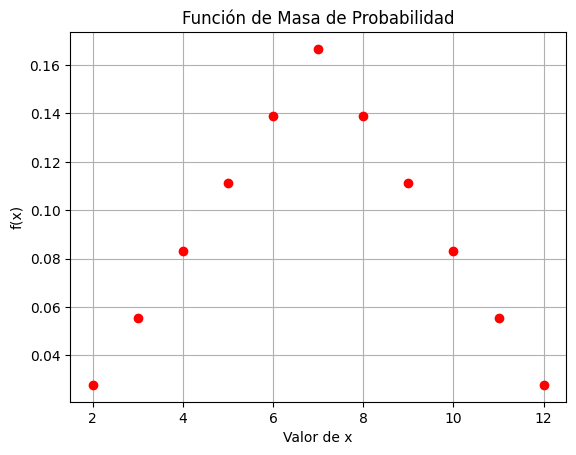

In [ ]:
import matplotlib.pyplot as plt

# Función de masa de probabilidad
def probabilidad(x):
    if x < 2 or x > 12:
        return 0
    elif x <= 7:
        return (x - 1) / 36
    else:
        return (13 - x) / 36

# Valores de x
valores_x = range(2, 13)

# Probabilidades correspondientes
probabilidades = [probabilidad(x) for x in valores_x]

# Graficar la función de masa de probabilidad
plt.plot(valores_x, probabilidades, 'ro')
plt.xlabel('Valor de x')
plt.ylabel('f(x)')
plt.title('Función de Masa de Probabilidad')
plt.grid()
plt.show()

El grafico de la distribución tambien podemos hacerlo mediante barras verticales

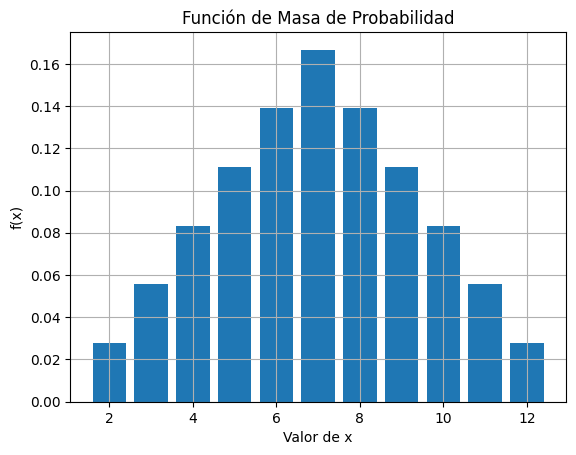

In [ ]:
import matplotlib.pyplot as plt

# Función de masa de probabilidad
def probabilidad(x):
    if x < 2 or x > 12:
        return 0
    elif x <= 7:
        return (x - 1) / 36
    else:
        return (13 - x) / 36

# Valores de x
valores_x = range(2, 13)

# Probabilidades correspondientes
probabilidades = [probabilidad(x) for x in valores_x]

# Graficar la función de masa de probabilidad
plt.bar(valores_x, probabilidades )
plt.xlabel('Valor de x')
plt.ylabel('f(x)')
plt.title('Función de Masa de Probabilidad')
plt.grid()
plt.show()

Claramete, note que en una distribución de probabilidad discreta, la variable aleatoria solo puede tomar valores aislados, por lo que su representación gráfica se realiza mediante puntos o barras ubicados en los posibles valores de la variable. La altura de cada punto o barra representa la probabilidad asociada a ese valor, $P(X=x)$. A diferencia de una distribución continua, no tiene sentido unir estos puntos mediante una curva, ya que entre dos valores posibles pueden existir valores que la variable aleatoria no puede tomar.



 ## 4. Distribución binomial

 ### 4.1. Experimetos de exitos o fracasos: ensayos de Bernoulli

Antes de estudiar la distribución binomial, consideremos el experimento aleatorio más sencillo que utilizaremos. Un **ensayo de Bernoulli** es un experimento que tiene únicamente dos resultados posibles. Podemos llamarlos:

- **éxito**, que representaremos mediante $1$;
- **fracaso**, que representaremos mediante $0$.

Si la probabilidad de éxito es $p$, entonces la probabilidad de fracaso es

$$
1-p.
$$

Definimos la variable aleatoria $X$ como

$$
X=
\begin{cases}
1, & \text{si ocurre un éxito},\\
0, & \text{si ocurre un fracaso}.
\end{cases}
$$

Por tanto,

$$
P(X=1)=p
$$

y

$$
P(X=0)=1-p.
$$

Esta distribución se denomina **distribución de Bernoulli**. Su función de masa de probabilidad puede escribirse de manera compacta como

$$
P(X=x)=p^x(1-p)^{1-x},
\qquad x\in\{0,1\}.
$$

La distribución de Bernoulli será el elemento fundamental para construir la distribución binomial.


* #### Ejemplo

Supongamos que un dispositivo electrónico tiene una probabilidad de $5\%$ de ser defectuoso.

Definimos

$$
X=
\begin{cases}
1, & \text{si el dispositivo es defectuoso},\\
0, & \text{si el dispositivo no es defectuoso}.
\end{cases}
$$

Entonces

$$
p=0.05
$$

y

$$
P(X=1)=0.05,
\qquad
P(X=0)=0.95.
$$

Cada dispositivo puede considerarse, bajo estas condiciones, como un ensayo de Bernoulli.


## 4.2. Definición de la distribución binomial

La distribución binomial aparece cuando repetimos un número determinado de veces un ensayo de Bernoulli.

Supongamos que realizamos $n$ ensayos independientes, cada uno con probabilidad de éxito $p$.

Definimos la variable aleatoria $X$ como el **número de éxitos obtenidos en los $n$ ensayos**.

Entonces $X$ puede tomar los valores

$$
0,1,2,\ldots,n.
$$

La variable aleatoria $X$ sigue una distribución binomial con parámetros $n$ y $p$, lo que escribimos como

$$
X\sim\operatorname{Bin}(n,p).
$$




##### ** Deducción de la distribución binomial**

La fórmula de la distribución binomial se obtiene directamente a partir de los ensayos de Bernoulli.

Supongamos que queremos calcular la probabilidad de obtener exactamente $x$ éxitos en $n$ ensayos.

Consideremos primero una secuencia particular en la que aparecen $x$ éxitos y $n-x$ fracasos. Por ejemplo, para $n=5$ y $x=2$, una posible secuencia es

$$
E,E,F,F,F.
$$

Como los ensayos son independientes, la probabilidad de esta secuencia particular es

$$
\underbrace{p\cdot p}_{2\text{ éxitos}}
\underbrace{(1-p)(1-p)(1-p)}_{3\text{ fracasos}},
$$

es decir,

$$
p^2(1-p)^3.
$$

En general, cualquier secuencia que contenga $x$ éxitos y $n-x$ fracasos tiene probabilidad

$$
p^x(1-p)^{n-x}.
$$

Pero existen diferentes formas de organizar esos $x$ éxitos dentro de los $n$ ensayos.

El número de formas posibles es

$$
\binom{n}{x}
=
\frac{n!}{x!(n-x)!}.
$$

Por tanto, sumando la probabilidad de todas las secuencias posibles obtenemos

$$
P(X=x)
=
\binom{n}{x}
p^x(1-p)^{n-x}.
$$

Esta es la **función de masa de probabilidad binomial**:

$$
\boxed{
P(X=x)
=
\binom{n}{x}
p^x(1-p)^{n-x}
}
$$

para

$$
x=0,1,\ldots,n.
$$

La distribución binomial, por tanto, no aparece como una fórmula aislada: se construye a partir de la repetición de ensayos de Bernoulli independientes.





* #### Ejemplo: dispositivos defectuosos

Supongamos que un fabricante de dispositivos electrónicos sabe por experiencia que la tasa de producción de dispositivos defectuosos es del $5\%$ y desea estimar la probabilidad de obtener exactamente $3$ dispositivos defectuosos en un lote de $10$ dispositivos seleccionados al azar.

Cada dispositivo puede considerarse un ensayo de Bernoulli, con

$$
p=0.05.
$$

Como seleccionamos $n=10$ dispositivos, definimos

$$
X=\text{número de dispositivos defectuosos}.
$$

Entonces

$$
X\sim\operatorname{Bin}(10,0.05).
$$

Queremos calcular

$$
P(X=3).
$$

Aplicamos la fórmula binomial:

$$
P(X=3)
=
\binom{10}{3}
(0.05)^3
(1-0.05)^7.
$$

Por tanto,

$$
P(X=3)
=
\frac{10!}{3!(10-3)!}
(0.05)^3
(0.95)^7.
$$

El resultado es aproximadamente

$$
P(X=3)\approx0.1176.
$$

Por lo tanto, la probabilidad de obtener exactamente $3$ dispositivos defectuosos en un lote de $10$ dispositivos es aproximadamente

$$
11.76\%.
$$



## 5. La distribucion de Poisson

La distribución binomial es útil cuando queremos modelar el número de éxitos en un número conocido de ensayos. Sin embargo, existen situaciones en las que el número de oportunidades para que ocurra un evento es muy grande, mientras que la probabilidad de que ocurra en cada oportunidad es muy pequeña.

Por ejemplo:

- número de llamadas recibidas por una central durante una hora;
- número de defectos en una determinada longitud de material;
- número de errores en una página;
- número de eventos que ocurren durante un intervalo de tiempo.

En estas situaciones podemos utilizar la **distribución de Poisson**.

La distribución de Poisson puede obtenerse como un caso límite de la distribución binomial.


### 5.1. De la distribución binomial a la distribución de Poisson

Partimos de la distribución binomial:

$$
P(X=x)
=
\binom{n}{x}
p^x(1-p)^{n-x}.
$$

Supongamos ahora que $n$ es muy grande y que la probabilidad $p$ de cada evento es muy pequeña.

Sin embargo, queremos mantener constante el número promedio de eventos. Para ello definimos

$$
\lambda=np.
$$

De aquí obtenemos

$$
p=\frac{\lambda}{n}.
$$

Sustituyendo en la expresión binomial:

$$
P(X=x)
=
\binom{n}{x}
\left(\frac{\lambda}{n}\right)^x
\left(1-\frac{\lambda}{n}\right)^{n-x}.
$$

Escribiendo el coeficiente binomial en términos de factoriales:

$$
P(X=x)
=
\frac{n!}{x!(n-x)!}
\frac{\lambda^x}{n^x}
\left(1-\frac{\lambda}{n}\right)^{n-x}.
$$

Para un valor fijo de $x$ y cuando $n$ crece, se obtiene

$$
\frac{n!}{(n-x)!n^x}\longrightarrow1
$$

y

$$
\left(1-\frac{\lambda}{n}\right)^n
\longrightarrow
e^{-\lambda}.
$$

Además,

$$
\left(1-\frac{\lambda}{n}\right)^{-x}
\longrightarrow1.
$$

Por tanto,

$$
P(X=x)
\longrightarrow
\frac{e^{-\lambda}\lambda^x}{x!}.
$$

Así obtenemos la distribución de Poisson:

$$
\boxed{
P(X=x)
=
\frac{e^{-\lambda}\lambda^x}{x!}
}
$$

para

$$
x=0,1,2,\ldots
$$

Este resultado explica por qué introducimos primero la distribución binomial: **la distribución de Poisson puede entenderse como una aproximación de la distribución binomial cuando el número de ensayos es muy grande, la probabilidad de éxito es muy pequeña y el producto $np$ permanece constante.**

En este contexto, $\lambda$ representa el número promedio de eventos que esperamos observar en el intervalo considerado.




## 5.2. Distribución de Poisson

La distribución de Poisson es una distribución de probabilidad discreta utilizada para modelar el número de veces que ocurre un evento durante un intervalo fijo de tiempo o espacio.

La variable aleatoria $X$ sigue una distribución de Poisson con parámetro $\lambda$ cuando

$$
X\sim\operatorname{Poisson}(\lambda).
$$

Su función de masa de probabilidad es

$$
\boxed{
P(X=x)
=
\frac{e^{-\lambda}\lambda^x}{x!}
}
$$

donde

- $x=0,1,2,\ldots$ representa el número de eventos observados;
- $\lambda>0$ representa el número promedio de eventos en el intervalo considerado;
- $e$ es la constante de Euler.

Para utilizar esta distribución debemos especificar claramente el intervalo de tiempo o espacio en el que estamos contando los eventos. El valor de $\lambda$ depende de ese intervalo.

La distribución de Poisson suele utilizarse bajo la idea de que los eventos ocurren de manera independiente y que la tasa promedio de ocurrencia permanece aproximadamente constante durante el intervalo considerado.


* #### Ejemplo: llamadas telefónicas

Supongamos que en promedio se reciben $10$ llamadas telefónicas cada $2$ horas en una central de atención al cliente.

Queremos determinar la probabilidad de que en un intervalo de $1$ hora se reciban exactamente $3$ llamadas.

Primero debemos expresar la tasa promedio en el intervalo que estamos estudiando.

Si se reciben $10$ llamadas cada $2$ horas, entonces se reciben en promedio

$$
\lambda=\frac{10}{2}=5
$$

llamadas por hora.

Por tanto, para un intervalo de $1$ hora tenemos

$$
\lambda=5.
$$

Definimos

$$
X=\text{número de llamadas recibidas durante una hora}.
$$

Entonces

$$
X\sim\operatorname{Poisson}(5).
$$

Queremos calcular

$$
P(X=3).
$$

Aplicando la fórmula de Poisson:

$$
P(X=3)
=
\frac{e^{-5}5^3}{3!}.
$$

Por tanto,

$$
P(X=3)
=
\frac{e^{-5}\cdot125}{6}
\approx0.14037.
$$

Así, la probabilidad de recibir exactamente $3$ llamadas durante una hora es aproximadamente

$$
14.037\%.
$$



### 5.3 La importancia de las unidades de $\lambda$

El parámetro $\lambda$ siempre debe corresponder al intervalo en el que estamos contando los eventos.

Por ejemplo, si una central recibe en promedio $32$ llamadas por minuto, entonces la tasa correspondiente a una hora es

$$
\lambda
=
32\,
\frac{\text{llamadas}}{\text{minuto}}
\times
60\,
\frac{\text{minutos}}{\text{hora}}
=
1920\,
\frac{\text{llamadas}}{\text{hora}}.
$$

Por tanto, para calcular una probabilidad asociada a una hora debemos utilizar $\lambda=1920$, y no $\lambda=32$.





## 6.1. Estimación de parámetros de distribuciones

La  inferencia estadística  es una rama de la estadística que se centra en obtener conclusiones sobre una población a partir de la información obtenida de una muestra representativa de esa población. En otras palabras, permite hacer estimaciones, tomar decisiones o sacar conclusiones sobre características o parámetros de una población a partir de los datos recopilados en una muestra.

En este curso utilizaremos el método de **máxima verosimilitud** (*Maximum Likelihood Estimation*, en inglés), que permite estimar los parámetros de un modelo estadístico a partir de un conjunto de datos observados. El objetivo es encontrar los valores de los parámetros que hacen más probable la obtención de los datos observados.

En esta sección introduciremos los conceptos básicos del método de máxima verosimilitud y lo aplicaremos para estimar el parametro de la dsitribucion de Poisson.


### 6.2. El método de máxima verosimilitud

El método de máxima verosimilitud se basa en la idea de que los valores de los parámetros que hacen más probable la ocurrencia de los datos observados son los más adecuados para estimarlos.

Para encontrar estos valores, se busca maximizar la **función de verosimilitud**, que describe la probabilidad de obtener los datos observados como función de los parámetros del modelo.

En el caso discreto, si tenemos $N$ observaciones $x_1,x_2,\ldots,x_N$ y suponemos que son realizaciones independientes de una variable aleatoria cuya distribución depende de un parámetro $\theta$, la función de verosimilitud se define como

$$
L(\theta)
=
\prod_{i=1}^{N} f(x_i;\theta),
$$

donde $f(x_i;\theta)$ representa la función de masa de probabilidad evaluada en la observación $x_i$, y $\theta$ es el parámetro que queremos estimar.

Para maximizar esta función directamente, tendríamos que derivar un producto de $N$ términos. Esto puede producir expresiones difíciles de manipular cuando el número de observaciones es grande.

Una forma conveniente de simplificar el cálculo consiste en utilizar el  logaritmo de la función de verosimilitud :

$$
\ln L(\theta)
=
\ln\left(
\prod_{i=1}^{N} f(x_i;\theta)
\right).
$$

Aplicando la propiedad del logaritmo de un producto obtenemos

$$
\ln L(\theta)
=
\sum_{i=1}^{N}
\ln\left(f(x_i;\theta)\right).
$$

De esta manera, en lugar de derivar un producto, debemos derivar una suma de $N$ términos. Además, como el logaritmo es una función creciente, $L(\theta)$ y $\ln L(\theta)$ alcanzan su máximo para el mismo valor de $\theta$.

Por tanto, podemos trabajar con la **log-verosimilitud** para estimar los parámetros de una distribución.



### 6.3. Estimación del parámetro de la distribución de Poisson

Supongamos que tenemos $N$ observaciones de un experimento y que la variable aleatoria $X$ toma los valores

$$
x_1,x_2,\ldots,x_N.
$$

Supongamos además que las observaciones siguen una distribución de Poisson. Es decir,

$$
P(X=x_i)
=
\frac{e^{-\lambda}\lambda^{x_i}}{x_i!},
$$

donde $\lambda$ es el parámetro de la distribución.

En este caso, la función de verosimilitud es

$$
L(\lambda)
=
\prod_{i=1}^{N}
\frac{e^{-\lambda}\lambda^{x_i}}{x_i!}.
$$

Reorganizando los términos,

$$
L(\lambda)
=
\frac{1}{x_1!x_2!\cdots x_N!}
e^{-\lambda N}
\lambda^{\sum_{i=1}^{N}x_i}.
$$

Tomamos ahora el logaritmo:

$$
\ln L(\lambda)
=
\ln\left(
\frac{1}{x_1!x_2!\cdots x_N!}
\right)
-\lambda N
+
\left(\sum_{i=1}^{N}x_i\right)\ln(\lambda).
$$

Derivando con respecto a $\lambda$,

$$
\frac{d\ln L(\lambda)}{d\lambda}
=
-N
+
\frac{\sum_{i=1}^{N}x_i}{\lambda}.
$$

Para encontrar el máximo, igualamos la derivada a cero:

$$
-N
+
\frac{\sum_{i=1}^{N}x_i}{\lambda}
=
0.
$$

De donde obtenemos

$$
\hat{\lambda}
=
\frac{\sum_{i=1}^{N}x_i}{N}.
$$

El lado derecho corresponde a la  media muestral, que se denota por

$$
\bar{x}
=
\frac{\sum_{i=1}^{N}x_i}{N}.
$$

Por tanto, el estimador de máxima verosimilitud del parámetro de una distribución de Poisson es

$$
\boxed{\hat{\lambda}=\bar{x}}.
$$

Es decir, para estimar el parámetro $\lambda$ de una distribución de Poisson podemos utilizar simplemente el promedio de los datos observados.



* #### Ejemplo

Supongamos que se realizan $10$ experimentos en un laboratorio para estudiar la tasa de reacciones químicas en una solución. En cada experimento se registra el número de reacciones químicas que ocurren durante un minuto.

Los resultados obtenidos son:

| Experimento | Reacciones |
|:---:|:---:|
| 1 | 20 |
| 2 | 40 |
| 3 | 30 |
| 4 | 60 |
| 5 | 50 |
| 6 | 20 |
| 7 | 10 |
| 8 | 30 |
| 9 | 40 |
| 10 | 20 |


###### **Problema:**

A partir de los resultados obtenidos:

- Encuentre la tasa media de reacciones por minuto, denotada como $\lambda$.
- Encuentre la probabilidad porcentual de que ocurran $m=25$ reacciones en un minuto.
- Encuentre la probabilidad porcentual de que ocurran $m=1918$ reacciones en una hora.
- Realice un gráfico que muestre la probabilidad de obtener diferentes números de reacciones en un intervalo de dos minutos, considerando un número de reacciones entre $10$ y $100$.


##### **Solución**

La tasa media de reacciones por minuto se obtiene mediante la media muestral:

$$
\hat{\lambda}
=
\bar{x}
=
\frac{
20+40+30+60+50+20+10+30+40+20
}{10}
=
32.
$$

Por tanto, estimamos que la tasa media es

$$
\boxed{
\hat{\lambda}=32\text{ reacciones/minuto}
}.
$$


1. Probabilidad de obtener $25$ reacciones en un minuto:

Como el intervalo de tiempo es de un minuto, utilizamos directamente $\lambda=32$. La probabilidad de obtener exactamente $25$ reacciones es

$$
P(X=25)
=
\frac{e^{-32}32^{25}}{25!}
\approx 0.034728.
$$

En términos porcentuales,

$$
\boxed{
P(X=25)\approx 3.47\%
}.
$$


2. Probabilidad de obtener $1918$ reacciones en una hora:

En este caso debemos cambiar la escala de tiempo del parámetro $\lambda$, que está expresado en reacciones por minuto, a reacciones por hora.

Como una hora tiene $60$ minutos,

$$
\lambda_{\text{hora}}
=
32
\frac{\text{reacciones}}{\text{minuto}}
\frac{60\text{ minutos}}{\text{hora}}
=
1920
\frac{\text{reacciones}}{\text{hora}}.
$$

Por tanto, la probabilidad de obtener exactamente $1918$ reacciones durante una hora es

$$
P(X=1918)
=
\frac{e^{-1920}1920^{1918}}{1918!}
\approx 0.009099.
$$

En términos porcentuales,

$$
\boxed{
P(X=1918)\approx 0.91\%
}.
$$


3. Número de reacciones en dos minutos:

Para estudiar el número de reacciones que pueden ocurrir durante dos minutos, debemos modificar nuevamente el parámetro de la distribución.

Como la tasa estimada es de $32$ reacciones por minuto, durante dos minutos esperamos

$$
\lambda_{\text{dos}}
=
2(32)
=
64
$$

reacciones.

Por tanto, el número de reacciones durante dos minutos se puede modelar mediante

$$
X\sim\operatorname{Poisson}(64).
$$

Para cada número de reacciones $m$, calculamos

$$
P(X=m)
=
\frac{e^{-64}64^m}{m!}.
$$

El siguiente código permite visualizar estas probabilidades para valores de $m$ entre $10$ y $100$:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Datos de muestra
muestra = [20, 40, 30, 60, 50, 20, 10, 30, 40, 20]

# Estimación del parámetro lambda usando la media muestral
lambda_estimado = np.mean(muestra)

print(
    "Parámetro estimado lambda:",
    lambda_estimado,
    "reacciones/min"
)

Parámetro estimado lambda: 32.0 reacciones/min



La probabilidad de obtener $25$ reacciones en un minuto se calcula mediante:

In [ ]:
# Probabilidad de obtener 25 reacciones en un minuto
valor_m1 = 25
probabilidad_m1 = poisson.pmf(valor_m1, lambda_estimado)

print(
    "Probabilidad porcentual de obtener",
    valor_m1,
    "reacciones en un minuto =",
    round(100 * probabilidad_m1, 2),
    "%"
)

Probabilidad porcentual de obtener 25 reacciones en un minuto = 3.47 %



Para calcular la probabilidad de obtener $1918$ reacciones en una hora, primero cambiamos la escala temporal:

In [ ]:
# Probabilidad de obtener 1918 reacciones en una hora
valor_m2 = 1918

lambda_estimado_hora = 60 * lambda_estimado
probabilidad_m2 = poisson.pmf(valor_m2, lambda_estimado_hora)

print(
    "Probabilidad porcentual para obtener",
    valor_m2,
    "reacciones en una hora =",
    round(100 * probabilidad_m2, 2),
    "%"
)

Probabilidad porcentual para obtener 1918 reacciones en una hora = 0.91 %


Finalmente, para estudiar las reacciones durante dos minutos:

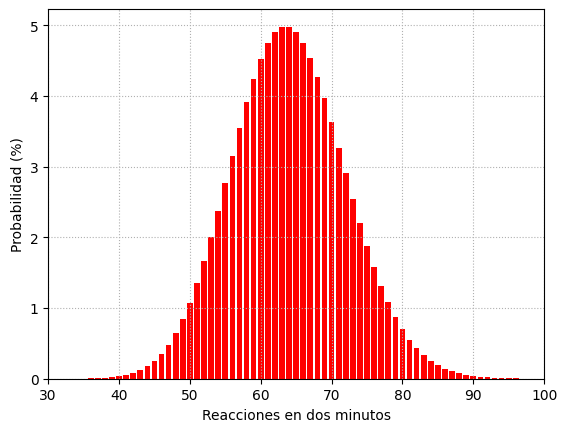

In [ ]:
# Parámetro correspondiente a dos minutos
lambda_estimado_dos = 2 * lambda_estimado

# Número de reacciones entre 10 y 100
numero_reacciones = np.arange(10, 101)

# Probabilidades porcentuales
probabilidades = 100 * poisson.pmf(
    numero_reacciones,
    lambda_estimado_dos
)

plt.bar(numero_reacciones, probabilidades, color='red')
plt.ylabel("Probabilidad (%)")
plt.xlabel("Reacciones en dos minutos")
plt.xlim([30, 100])
plt.xticks(range(30, 101, 10))
plt.grid(linestyle=':')
plt.show()



El modelo utilizado en este último caso es

$$
X\sim\operatorname{Poisson}(64).
$$

Para una distribución de Poisson con $\lambda=64$, los valores modales son $63$ y $64$. Por tanto, el gráfico muestra que el número de reacciones más probable durante dos minutos se encuentra alrededor de **64 reacciones**.


##### **Algunas funciones utilizadas en este codigo**

En el código aparecen dos elementos importantes:

- **`poisson`** es un objeto de `scipy.stats` que representa la distribución de Poisson y proporciona diferentes métodos para trabajar con ella. Por ejemplo, `poisson.pmf(k, mu)` calcula la probabilidad de obtener exactamente $k$ eventos cuando el parámetro de la distribución es $\mu$.

- **`plt.bar(x, y)`** genera un gráfico de barras. En `plt.bar(numero_reacciones, probabilidades, color='red')`, `numero_reacciones` contiene los valores posibles de la variable aleatoria y `probabilidades` contiene las probabilidades correspondientes. El argumento `color='red'` establece el color de las barras en rojo.




### 6.4. Valor esperado y varianza de la distribucion de Poisson

Para una variable aleatoria con distribución de Poisson, $
X\sim\operatorname{Poisson}(\lambda),$ el valor esperado y la varianza están dados por

$$
\mathbb{E}[X]= \operatorname{Var}(X)= \lambda.
$$

El **valor esperado** representa el número promedio de eventos que se obtendría al repetir muchas veces el experimento bajo las mismas condiciones. **La    varianza** mide qué tan variable es el número de eventos entre las diferentes realizaciones.

CLaramente, de la ecuacion anterior, tenemos que el valor esperado y la varianza son iguales, $\mathbb{E}[X]=\operatorname{Var}(X)=\lambda$. Esto significa que, al aumentar la tasa promedio de eventos, también aumenta la variabilidad absoluta del número de eventos. Sin embargo, la desviación estándar es $\sigma=\sqrt{\lambda}$, por lo que la variabilidad relativa disminuye a medida que $\lambda$ aumenta. Así, aunque un mayor número esperado de eventos implica una mayor dispersión, esta representa una proporción cada vez menor del valor esperado.



* #### Ejemplo: defectos en una línea de producción

En una fábrica se producen componentes electrónicos. Se observa que, en promedio, aparecen 4 componentes defectuosos por cada 1000 componentes producidos, y se supone que los defectos ocurren de manera independiente.

Sea $N$ el número de componentes defectuosos encontrados al revisar un lote de $2000$ componentes. Entonces,

$$
N\sim\operatorname{Poisson}(\lambda),
\qquad
\lambda=8.
$$

Por tanto,

$$
N\sim\operatorname{Poisson}(8).
$$

El valor esperado es

$$
\mathbb{E}[N]=\lambda=8.
$$

Podemos representar la distribución y señalar este valor:


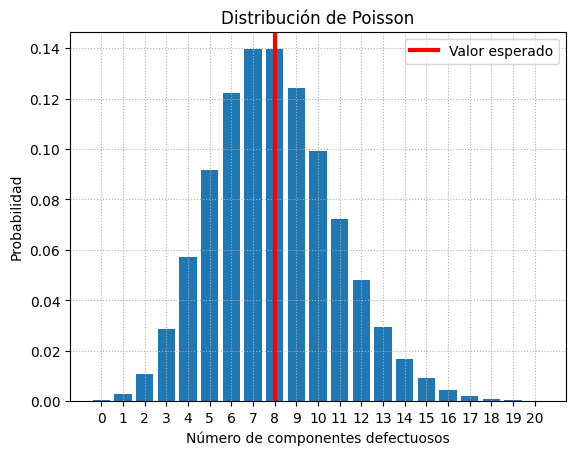

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parámetro de la distribución
lambda_ = 8

# Valores posibles de N
n = np.arange(0, 21)

# Probabilidades
probabilidades = poisson.pmf(n, lambda_)

# Gráfica de la distribución
plt.bar(n, probabilidades)

# Valor esperado
plt.axvline(
    lambda_,
    linestyle="-",
    label="Valor esperado", color='red', linewidth=3
)

plt.xlabel("Número de componentes defectuosos")
plt.ylabel("Probabilidad")
plt.title("Distribución de Poisson")
plt.xticks(n)
plt.grid(linestyle=":")
plt.legend()
plt.show()


##### **Interpretación del valor esperado mediante simulación***

Podemos repetir muchas veces el experimento y calcular el promedio del número de reacciones obtenido. A medida que aumenta el número de experimentos, este promedio se aproxima al valor esperado,

$$
\mathbb{E}[N]=\lambda=8.
$$



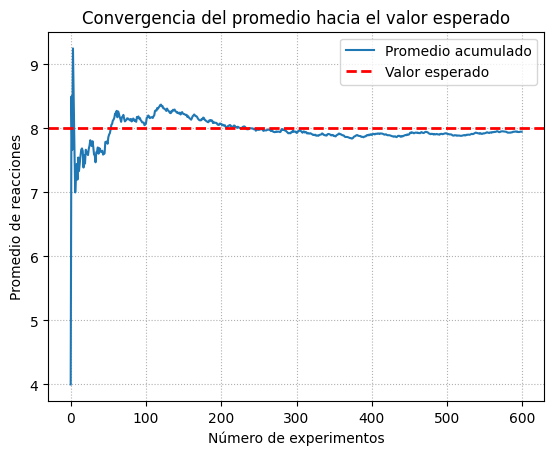

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

lambda_ = 8
rng = np.random.default_rng(123)

# Número de experimentos
experimentos = 600

# Simular el número de reacciones en cada experimento
reacciones = rng.poisson(lambda_, experimentos)

# Promedio acumulado
promedio = np.cumsum(reacciones) / np.arange(1, experimentos + 1)

# Gráfica
plt.plot(promedio, label="Promedio acumulado")
plt.axhline(
    lambda_,
    linestyle="--",
    label="Valor esperado", color='red', linewidth=2
)

plt.xlabel("Número de experimentos")
plt.ylabel("Promedio de reacciones")
plt.title("Convergencia del promedio hacia el valor esperado")
plt.legend()
plt.grid(linestyle=":")
plt.show()




Al principio, el promedio puede alejarse del valor esperado debido a la variabilidad aleatoria. Sin embargo, al aumentar el número de experimentos, el promedio acumulado tiende a acercarse a $\lambda=8$.



## 7. Procesos de Poisson

Hasta ahora hemos utilizado la distribución de Poisson para modelar el número de eventos que ocurren en un intervalo determinado. Sin embargo, en muchas situaciones no solamente interesa conocer cuántos eventos ocurren, sino también describir **cómo se producen a medida que transcurre el tiempo**. Para esto se introduce el **proceso de Poisson**.


Un proceso de Poisson es un modelo probabilístico que describe la ocurrencia de eventos aleatorios a lo largo del tiempo. Se supone que los eventos ocurren de manera independiente y con una tasa promedio constante $\lambda$ por unidad de tiempo. Si $N(t)$ representa el número de eventos ocurridos desde el instante $0$ hasta el instante $t$, entonces, para un intervalo de duración $t$,


$$
N(t)\sim\operatorname{Poisson}(\lambda t).
$$


Por tanto, la distribución de Poisson aparece naturalmente dentro del proceso de Poisson:

> permite describir cuántos eventos ocurren durante un intervalo, mientras que el proceso de Poisson describe  cómo se acumulan esos eventos a lo largo del tiempo.


### 7.1. Distribución de Poisson y proceso de Poisson

Es importante distinguir ambos conceptos. La  distribución de Poisson  es una distribución de probabilidad que permite responder preguntas como:

> ¿Cuál es la probabilidad de que ocurran exactamente $k$ eventos durante una hora?

Si la tasa promedio es $\lambda$ eventos por unidad de tiempo, entonces

$$
P(N(t)=k)
=
\frac{(\lambda t)^k e^{-\lambda t}}{k!}.
$$

El **proceso de Poisson**, en cambio, considera una sucesión de eventos a medida que transcurre el tiempo. La variable $N(t)$ representa el número acumulado de eventos hasta el instante $t$:

```text
Número de eventos
      │
  5   │                         ●
      │
  4   │                  ●
      │
  3   │            ●
      │
  2   │       ●
      │
  1   │  ●
      │
  0   └─────────────────────────────→ tiempo
          t₁    t₂    t₃    t₄    t₅
```

Así, podemos resumir la diferencia de la siguiente manera:

* $
\boxed{
\text{Distribución de Poisson}=\text{número de eventos en un intervalo}
}
$

* $\boxed{
\text{Proceso de Poisson}=\text{evolución del número de eventos en el tiempo}
}
$

La distribución de Poisson puede entenderse, entonces, como una "fotografía" del proceso en un intervalo determinado, mientras que el proceso de Poisson describe la evolución completa de los eventos.



### 7.2. Características del proceso de Poisson

Un proceso de Poisson con tasa $\lambda$ se caracteriza, en particular, por las siguientes propiedades:

1. **No hay eventos al comienzo:** $N(0)=0$.

2. **Incrementos independientes:** el número de eventos que ocurre en intervalos de tiempo que no se superponen es independiente. Por ejemplo, el número de eventos entre $0$ y $1$ minuto es independiente del número de eventos entre $2$ y $3$ minutos.

3. **Tasa constante:** el número esperado de eventos en un intervalo de duración $t$ es

   $$
   E[N(t)]=\lambda t.
   $$

4. **Distribución de los conteos:** el número de eventos en un intervalo de duración $t$ sigue una distribución de Poisson:

   $$
   N(t)\sim\operatorname{Poisson}(\lambda t).
   $$

5. **Eventos individuales en intervalos pequeños:** si $\Delta t$ es muy pequeño, la probabilidad de que ocurra un evento durante ese intervalo es aproximadamente

   $$
   P(\text{un evento en }\Delta t)\approx\lambda\Delta t,
   $$

   mientras que la probabilidad de que ocurran dos o más eventos es mucho menor.

Estas propiedades hacen que el proceso de Poisson sea apropiado para modelar fenómenos en los que los eventos ocurren de manera aleatoria, independiente y con una tasa promedio aproximadamente constante.



* #### Ejemplo: aparición de mutaciones en una secuencia de ADN

Las mutaciones son cambios que pueden producirse en una secuencia de ADN durante los procesos de replicación y transcripción. Supongamos que queremos estudiar la aparición de mutaciones en una determinada región de ADN a medida que transcurre el tiempo.

Para simplificar el problema, asumiremos que las mutaciones aparecen de manera aleatoria, independientemente unas de otras y con una tasa promedio constante.

Sea

$$
N(t)=\text{número de mutaciones observadas desde el instante }0\text{ hasta }t.
$$

Supongamos que, a partir de observaciones experimentales, se estima que aparecen en promedio

$$
\lambda=2
$$

mutaciones por hora.

Bajo estas condiciones, podemos modelar la aparición de mutaciones mediante un   proceso de Poisson.


###### **Modelamiento matematico del proceso**

Si la tasa de aparición es $\lambda=2$ mutaciones por hora, entonces

$$
N(t)\sim\operatorname{Poisson}(2t).
$$

Por ejemplo, durante un período de $3$ horas,

$$
N(3)\sim\operatorname{Poisson}(6).
$$

Por tanto, la probabilidad de observar exactamente $4$ mutaciones durante esas tres horas es

$$
P(N(3)=4)
=
\frac{6^4e^{-6}}{4!}.
$$

Podemos calcularla en Python:




In [ ]:
from scipy.stats import poisson

# Tasa de mutaciones por hora
lambda_ = 2

# Duración del intervalo
t = 3

# Número de mutaciones
k = 4

# Parámetro de la distribución de Poisson
mu = lambda_ * t

# Probabilidad de observar exactamente k mutaciones
probabilidad = poisson.pmf(k, mu)

print("Probabilidad =", probabilidad)

En este punto estamos utilizando la distribución de Poisson para estudiar el número de mutaciones durante un intervalo. Pero el proceso de Poisson permite estudiar algo más: los instantes en los que aparecen las mutaciones.



###### **Simulación del proceso de Poisson**

En un proceso de Poisson, los tiempos entre eventos consecutivos siguen una distribución exponencial. Por tanto, podemos simular los tiempos de aparición de las mutaciones y construir el número acumulado de mutaciones.

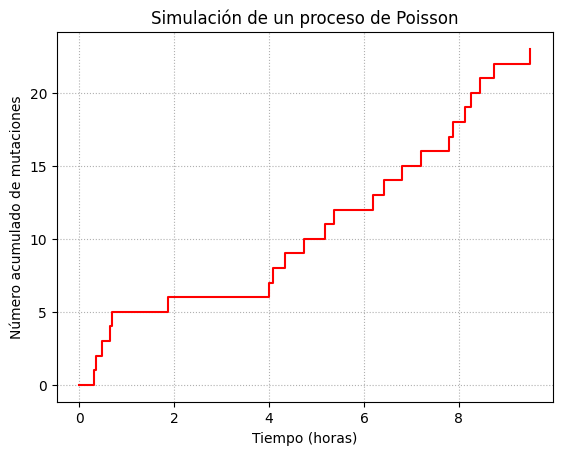

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Tasa de mutaciones por hora
lambda_ = 2

# Tiempo total de observación
tiempo_total = 10

# Generador de números aleatorios
rng = np.random.default_rng(123)

# Tiempos entre mutaciones
tiempos_entre_mutaciones = rng.exponential(
    scale=1 / lambda_,
    size=100
)

# Tiempos acumulados de aparición
tiempos_mutaciones = np.cumsum(
    tiempos_entre_mutaciones
)

# Conservar las mutaciones dentro del intervalo
tiempos_mutaciones = tiempos_mutaciones[ tiempos_mutaciones <= tiempo_total ]

# Número acumulado de mutaciones
numero_mutaciones = np.arange(  1,  len(tiempos_mutaciones) + 1 )

# Representación del proceso
plt.step(
    np.concatenate(([0], tiempos_mutaciones)),
    np.concatenate(([0], numero_mutaciones)),
    where="post", color='red'
)

plt.xlabel("Tiempo (horas)")
plt.ylabel("Número acumulado de mutaciones")
plt.title("Simulación de un proceso de Poisson")
plt.grid(linestyle=':')
plt.show()



##### **Funciones utilizadas en la simulación**

 En la simulación anterior aparecen algunas funciones de **NumPy** y **Matplotlib** que conviene conocer:

- `rng.exponential(scale=...)` genera números aleatorios con distribución exponencial. En este caso, `scale=1/lambda_` corresponde al tiempo promedio entre dos mutaciones consecutivas.

- `np.cumsum()` calcula la suma acumulada de los elementos de un arreglo. Si tenemos los tiempos entre mutaciones, permite obtener los tiempos en los que ocurre cada mutación.

- `np.concatenate()` permite unir arreglos. En el ejemplo se utiliza para agregar el punto inicial $(0,0)$ a los datos que representan el proceso.

- `plt.step()` genera una gráfica escalonada. Es apropiada para representar un proceso de Poisson porque el número acumulado de eventos permanece constante entre dos mutaciones y aumenta en una unidad cada vez que ocurre una nueva mutación.






Cada salto de la gráfica representa la aparición de una nueva mutación. La función obtenida es una realización particular del proceso de Poisson.

###### **Discusión**

El ejemplo permite distinguir los dos conceptos. La distribución de Poisson responde preguntas sobre el número de mutaciones que ocurren durante un intervalo determinado. El **proceso de Poisson**, en cambio, describe cómo esas mutaciones aparecen y se acumulan a medida que transcurre el tiempo.

En particular,

$$
\boxed{
N(t)\sim\operatorname{Poisson}(\lambda t)
}
$$

relaciona ambos conceptos: para cada intervalo de duración $t$, el número de eventos del proceso sigue una distribución de Poisson.

Como todo modelo matemático, esta representación es una simplificación. En un sistema biológico real, la tasa de mutación puede variar y los eventos pueden presentar dependencias. El proceso de Poisson resulta útil como modelo idealizado para estudiar la ocurrencia aleatoria de eventos a lo largo del tiempo.


* #### Ejemplo: detección de partículas mediante un proceso de Poisson

Un detector registra partículas que llegan de manera aleatoria. Supongamos que, en promedio, se detectan $120$ partículas por segundo y que las detecciones son independientes. Queremos modelar el número de partículas detectadas a medida que transcurre el tiempo.

Sea
$$
N(t)=\text{número de partículas detectadas desde el instante }0\text{ hasta }t.
$$

##### **Modelo matemático del proceso**

Como las partículas se detectan de manera independiente y la tasa promedio es constante, podemos modelar las detecciones mediante un proceso de Poisson con tasa

$$
\lambda=120\quad\text{partículas/s}.
$$

Por tanto,

$$
N(t)\sim\operatorname{Poisson}(120t).
$$

Por ejemplo, durante $0.05$ segundos,

$$
N(0.05)\sim\operatorname{Poisson}(6).
$$

La probabilidad de detectar exactamente $8$ partículas durante este intervalo es

$$
P(N(0.05)=8)
=
\frac{6^8e^{-6}}{8!}.
$$

Podemos calcularla con Python:

In [ ]:
from scipy.stats import poisson

lambda_ = 120
t = 0.05
k = 8

mu = lambda_ * t
probabilidad = poisson.pmf(k, mu)

print("Probabilidad =", probabilidad)

Probabilidad = 0.1032577335308442



El proceso de Poisson también permite estudiar cuándo ocurren las detecciones. Los tiempos entre detecciones consecutivas siguen una distribución exponencial con parámetro $\lambda$.

##### **Simulación del proceso**

Podemos simular los tiempos entre partículas y construir el número acumulado de detecciones.

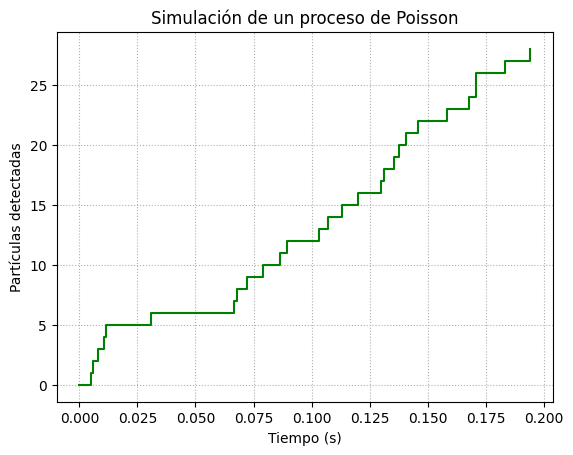

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

lambda_ = 120
tiempo_total = 0.2

rng = np.random.default_rng(123)

tiempos_entre_particulas = rng.exponential(
    scale=1 / lambda_,
    size=100
)

tiempos = np.cumsum(tiempos_entre_particulas)
tiempos = tiempos[tiempos <= tiempo_total]

numero = np.arange(1, len(tiempos) + 1)

plt.step(
    np.concatenate(([0], tiempos)),
    np.concatenate(([0], numero)),
    where="post" , color='green'
)

plt.xlabel("Tiempo (s)")
plt.ylabel("Partículas detectadas")
plt.title("Simulación de un proceso de Poisson")
plt.grid(linestyle=':')
plt.show()




##### **Discusión**

Cada salto de la gráfica representa la detección de una nueva partícula. La trayectoria mostrada corresponde a una **realización particular** del proceso de Poisson; por ello, otra simulación produciría tiempos de detección diferentes.

La distribución de Poisson permite determinar cuántas partículas se detectan durante un intervalo de tiempo, mientras que el proceso de Poisson permite representar cómo se producen y se acumulan esas detecciones a lo largo del tiempo.

Además de calcular probabilidades, el modelo permite estudiar cómo cambia el número esperado de partículas y su variabilidad a medida que transcurre el tiempo. Como

$$
N(t)\sim\operatorname{Poisson}(\lambda t),
$$

y para una distribución de Poisson el valor esperado y la varianza son iguales a su parámetro, se tiene

$$
\mathbb{E}[N(t)]
=
\operatorname{Var}(N(t))
=
\lambda t.
$$

En este caso, $\lambda=120$ partículas/s, por lo que

$$
\mathbb{E}[N(t)]=\operatorname{Var}(N(t))=120t,
$$

El valor esperado representa el número promedio de partículas que se detectarían hasta el tiempo $t$ si el experimento se repitiera muchas veces bajo las mismas condiciones. Por ejemplo, después de $0.05$ segundos,

$$
\mathbb{E}[N(0.05)]=6.
$$

Esto no significa que necesariamente se detecten exactamente $6$ partículas en cada realización, sino que $6$ es el promedio esperado al repetir el experimento muchas veces. Por otra parte, la varianza mide la  variabilidad del número de partículas detectadas entre diferentes realizaciones. En este caso,

$$
\operatorname{Var}(N(0.05))=6.
$$

Que el valor esperado y la varianza sean iguales significa que, en un proceso de Poisson, la variabilidad del número de eventos está directamente relacionada con la cantidad promedio de eventos. Además, ambas cantidades aumentan linealmente con el tiempo: al observar durante un intervalo más largo, se espera detectar más partículas y también aumenta la variabilidad en el número detectado.







### 7.3 Resumen: de Bernoulli a procesos de Poisson

Los modelos de Bernoulli, binomial y Poisson están relacionados y permiten describir situaciones cada vez más generales.

```text
Ensayo de Bernoulli
        │
        │ n ensayos independientes
        ▼
Distribución binomial
        │
        │ n grande, p pequeño
        │ λ = np constante
        ▼
Distribución de Poisson
        │
        │ eventos distribuidos en un intervalo
        ▼
Proceso de Poisson
```

La relación fundamental entre las distribuciones binomial y de Poisson es

$$
\boxed{
\operatorname{Binomial}(n,p)
\quad\xrightarrow[n\to\infty,\;p\to0]{np=\lambda}\quad
\operatorname{Poisson}(\lambda)
}
$$

En términos de las preguntas que responde cada modelo:

| Modelo | ¿Qué se observa? | Situación típica |
|:---|:---|:---|
| **Bernoulli** | Un solo ensayo con dos resultados posibles: éxito o fracaso. | ¿Una pieza es defectuosa? |
| **Binomial** | El número de éxitos en $n$ ensayos independientes. | ¿Cuántas piezas defectuosas hay entre $100$? |
| **Poisson** | El número de eventos que ocurren en un intervalo. | ¿Cuántas llamadas llegan en una hora? |
| **Proceso de Poisson** | La ocurrencia y acumulación de eventos a medida que transcurre el tiempo. | ¿Cómo se acumulan las llamadas durante una jornada? |


En resumen,

$$
\boxed{
\text{Bernoulli}
\longrightarrow
\text{Binomial}
\longrightarrow
\text{Poisson}
\longrightarrow
\text{Proceso de Poisson}
}
$$


Cada paso amplía la situación que podemos modelar:

- **Bernoulli:** un único ensayo.
- **Binomial:** varios ensayos independientes.
- **Poisson:** conteo de eventos en un intervalo cuando estos son poco frecuentes.
- **Proceso de Poisson:** evolución temporal de esos eventos.

Así, la distribución de Poisson no debe verse únicamente como una aproximación de la distribución binomial. También constituye el elemento fundamental para describir los conteos dentro de un proceso de Poisson.




## 8. Ejercicios

### Ejercicio 1. Probabilidad clásica: lanzamiento de dados

Se lanzan dos dados justos.

1. Calcule la probabilidad de obtener una suma igual a $8$.
2. Calcule la probabilidad de obtener una suma mayor que $9$.
3. Calcule la probabilidad de obtener una suma par.
4. Determine el espacio muestral y explique por qué el enfoque clásico permite calcular estas probabilidades.

### Ejercicio 2. Probabilidad clásica: cartas

De una baraja estándar de $52$ cartas se extrae una carta al azar.

1. Calcule la probabilidad de obtener un as.
2. Calcule la probabilidad de obtener una carta de corazones.
3. Calcule la probabilidad de obtener un as de corazones.
4. Compare las tres probabilidades obtenidas.

### Ejercicio 3. Enfoque frecuentista

Una máquina produce piezas y se inspeccionan $500$ piezas. Se encuentran $18$ piezas defectuosas.

1. Utilice el enfoque frecuentista para estimar la probabilidad de que una pieza producida por la máquina sea defectuosa.
2. Utilice esta estimación para estimar cuántas piezas defectuosas se esperarían en un lote de $2000$ piezas.
3. Explique por qué esta estimación puede cambiar si se inspecciona un nuevo conjunto de piezas.

### Ejercicio 4. Ensayo de Bernoulli

Una prueba médica tiene una probabilidad de $0.92$ de producir un resultado positivo cuando se realiza bajo determinadas condiciones.

Defina una variable aleatoria de Bernoulli $X$ que represente el resultado de la prueba.

1. Especifique los valores posibles de $X$.
2. Determine $P(X=1)$ y $P(X=0)$.
3. Escriba la función de masa de probabilidad de $X$.
4. Explique qué representan el éxito y el fracaso en este contexto.

### Ejercicio 5. Bernoulli aplicado a control de calidad

Una fábrica produce componentes electrónicos y la probabilidad de que un componente sea defectuoso es $p=0.02$.

Se selecciona un componente al azar.

1. Defina una variable aleatoria de Bernoulli para representar el resultado.
2. Calcule la probabilidad de que el componente sea defectuoso.
3. Calcule la probabilidad de que el componente no sea defectuoso.

### Ejercicio 6. Distribución binomial

Una empresa produce bombillas y estima que el $4\%$ de las bombillas presentan algún defecto.

Se seleccionan aleatoriamente $20$ bombillas.

Defina $X$ como el número de bombillas defectuosas.

1. Explique por qué puede utilizarse una distribución binomial.
2. Identifique los valores de $n$ y $p$.
3. Calcule la probabilidad de encontrar exactamente $2$ bombillas defectuosas.
4. Calcule la probabilidad de que ninguna bombilla sea defectuosa.
5. Calcule la probabilidad de encontrar al menos una bombilla defectuosa.

### Ejercicio 7. Binomial y datos experimentales

En un experimento se realizan $100$ ensayos de Bernoulli y se observan $12$ éxitos.

1. Estime la probabilidad $p$ mediante el enfoque frecuentista.
2. Suponga que esta estimación es válida para nuevos experimentos.
3. Si se realizan $20$ nuevos ensayos, modele el número de éxitos mediante una distribución binomial.
4. Calcule la probabilidad de obtener exactamente $3$ éxitos.

### Ejercicio 8. Aproximación de la Binomial por Poisson

Una determinada bacteria tiene una probabilidad muy pequeña de aparecer en cada unidad de una muestra.

Suponga que existen $1000$ unidades independientes y que la probabilidad de aparición de la bacteria en cada unidad es

$$
p=0.002.
$$

1. Modele el número de unidades que contienen la bacteria utilizando una distribución binomial.
2. Calcule el valor de $np$.
3. Utilice una distribución de Poisson para aproximar la distribución binomial.
4. Calcule, mediante la aproximación de Poisson, la probabilidad de encontrar exactamente $3$ unidades con la bacteria.
5. Explique por qué la aproximación de Poisson resulta razonable en este caso.

### Ejercicio 9. Distribución de Poisson: llamadas

Una central telefónica recibe en promedio $12$ llamadas por hora.

Suponga que las llamadas cumplen las condiciones necesarias para utilizar un modelo de Poisson.

1. Defina una variable aleatoria apropiada.
2. Determine el parámetro $\lambda$ para un intervalo de una hora.
3. Calcule la probabilidad de recibir exactamente $8$ llamadas en una hora.
4. Calcule la probabilidad de no recibir ninguna llamada en una hora.
5. Calcule la probabilidad de recibir al menos una llamada.

### Ejercicio 10. Poisson y cambio de escala temporal

Una página web recibe en promedio $120$ visitas cada hora.

Suponga que el número de visitas puede modelarse mediante una distribución de Poisson.

1. Determine el número promedio de visitas durante $10$ minutos.
2. Determine el parámetro $\lambda$ correspondiente a un intervalo de $10$ minutos.
3. Calcule la probabilidad de recibir exactamente $15$ visitas durante esos $10$ minutos.
4. Calcule la probabilidad de recibir más de $15$ visitas.
5. Explique por qué no se debe utilizar directamente $\lambda=120$ para realizar los cálculos correspondientes a un intervalo de $10$ minutos.



#### Ejercicio 11.  Llegada de clientes a una cafetería

Durante $10$ intervalos consecutivos de $5$ minutos se registró el número de clientes que llegaron a una cafetería.

| Intervalo | Clientes |
|:---:|:---:|
| 1 | 4 |
| 2 | 3 |
| 3 | 6 |
| 4 | 5 |
| 5 | 2 |
| 6 | 7 |
| 7 | 4 |
| 8 | 5 |
| 9 | 3 |
| 10 | 6 |

1. Calcule la tasa promedio de llegada de clientes por minuto.

2. Suponga que las llegadas pueden modelarse mediante un proceso de Poisson. Determine la probabilidad de que lleguen exactamente $8$ clientes durante un período de $10$ minutos.

3. Simule en Python una realización del proceso durante una hora y grafique el número acumulado de clientes.

4. Compare la simulación con los datos de la tabla.




#### Ejercicio 12. Aparición de reacciones químicas

En un experimento químico se registra el número de reacciones que ocurren durante intervalos consecutivos de $2$ segundos.

| Intervalo | Reacciones |
|:---:|:---:|
| 1 | 3 |
| 2 | 5 |
| 3 | 4 |
| 4 | 2 |
| 5 | 6 |
| 6 | 3 |
| 7 | 5 |
| 8 | 4 |
| 9 | 3 |
| 10 | 5 |

Se desea determinar si un **proceso de Poisson** puede ser utilizado como modelo para describir la aparición de estas reacciones.

1. Estime la tasa promedio de reacciones por segundo a partir de los datos.

2. Suponga inicialmente que las reacciones siguen un proceso de Poisson con tasa constante. Determine la probabilidad de observar exactamente $7$ reacciones durante un intervalo de $2$ segundos.

3. Simule en Python una realización del proceso durante $20$ segundos y grafique el número acumulado de reacciones.

4. Compare la cantidad de reacciones observada en cada intervalo con la cantidad esperada por el modelo.

5. Calcule la media y la varianza de los datos de la tabla. ¿Son aproximadamente iguales? ¿Qué relación tiene esta comparación con la elección de un proceso de Poisson?

6. Suponga ahora que durante los primeros $10$ segundos la reacción ocurre con una tasa diferente a la de los últimos $10$ segundos. ¿Los datos proporcionan alguna evidencia que permita considerar esta posibilidad? Discuta qué implicaría esto para el modelo de Poisson utilizado en los puntos anteriores.

